<a href="https://colab.research.google.com/github/Mai732/ML-AI/blob/main/assignment_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Load the Dataset
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
print("First 5 rows:")
print(df.head())

print(f"\nNumber of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1] - 1}")
print(f"Number of classes: 2")
print(f"\nClass distribution:\n{df['target'].value_counts()}")
print("\n0 = Malignant, 1 = Benign")
print("\nPrediction problem: Binary classification to predict whether a breast tumor is Malignant (0) or Benign (1) based on 30 numerical features.")

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \


In [ ]:
# Step 2: Clean the Data
print("Missing values:\n", df.isnull().sum().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print("\nData types:\n", df.dtypes.value_counts())
print("\nAll features are numerical: Yes")
print(f"Target classes: {df['target'].unique()}")

df = df.drop_duplicates()

print(f"\nFinal dataset shape after cleaning: {df.shape}")

Missing values:
 0

Duplicate rows: 0

Data types:
 float64    30
int64       1
Name: count, dtype: int64

All features are numerical: Yes
Target classes: [0 1]

Final dataset shape after cleaning: (569, 31)


/tmp/ipykernel_30967/1927108272.py:15: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df[selected_features + ['target']].boxplot(by='target', ax=axes[1,0])


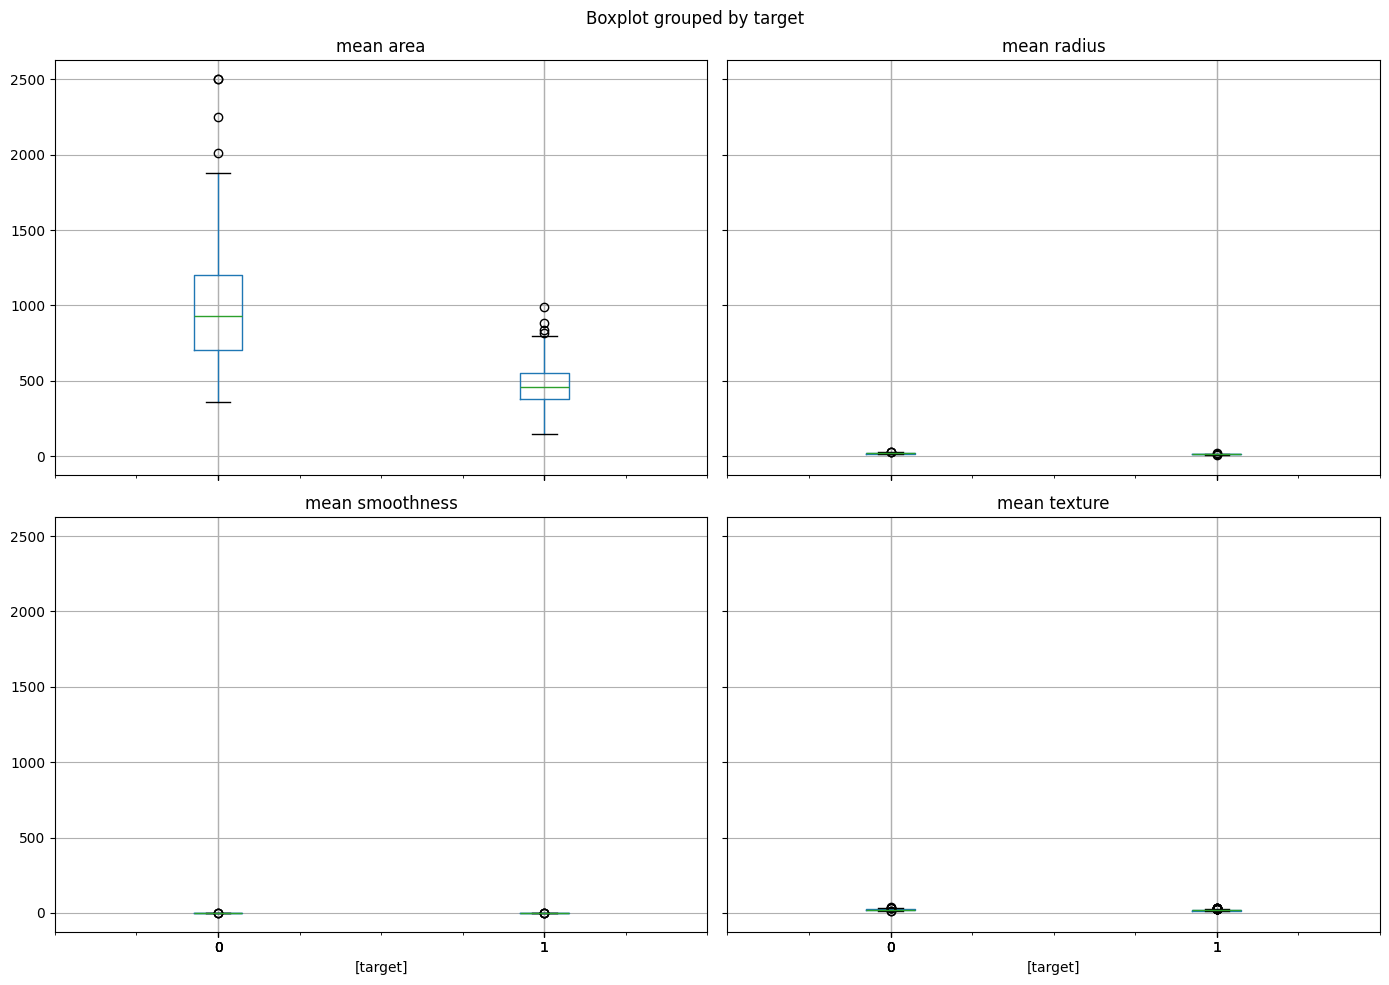


EDA Summary:
1. Classes: Slightly imbalanced (more benign cases)
2. Highly correlated features: Many features show strong correlation (e.g., radius, area, perimeter)
3. Visible outliers: Some features have outliers (seen in boxplots)
4. Useful features: mean radius, mean area, mean perimeter, mean concave points appear very discriminative


In [ ]:
# Step 3: Perform Simple EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Class distribution plot
df['target'].value_counts().plot(kind='bar', ax=axes[0,0], color=['red', 'green'])
axes[0,0].set_title('Class Distribution (0=Malignant, 1=Benign)')
axes[0,0].set_xlabel('Class')
axes[0,0].set_ylabel('Count')

corr = df.iloc[:, :-1].corr()
sns.heatmap(corr, ax=axes[0,1], cmap='coolwarm', cbar_kws={'shrink': 0.8})
axes[0,1].set_title('Feature Correlation Heatmap')

selected_features = ['mean radius', 'mean texture', 'mean area', 'mean smoothness']
df[selected_features + ['target']].boxplot(by='target', ax=axes[1,0])
axes[1,0].set_title('Boxplots by Class')
axes[1,0].set_xlabel('Class')
axes[1,0].set_ylabel('Values')

for i, feat in enumerate(selected_features[:4]):
    axes[1,1].hist(df[df['target']==0][feat], alpha=0.5, label=f'Malignant {feat}', bins=20)
    axes[1,1].hist(df[df['target']==1][feat], alpha=0.5, label=f'Benign {feat}', bins=20)
axes[1,1].set_title('Feature Distributions by Class')
axes[1,1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

print("\nEDA Summary:")
print("1. Classes: Slightly imbalanced (more benign cases)")
print("2. Highly correlated features: Many features show strong correlation (e.g., radius, area, perimeter)")
print("3. Visible outliers: Some features have outliers (seen in boxplots)")
print("4. Useful features: mean radius, mean area, mean perimeter, mean concave points appear very discriminative")

In [ ]:
# Step 4: Prepare the Features and Target
X = df.drop('target', axis=1)
y = df['target']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nCategorical features: None (all numerical)")
print(f"Target values: 0 (Malignant) and 1 (Benign)")

print("\nOutlier handling: Keeping outliers as ANN is robust to moderate outliers")

Features shape: (569, 30)
Target shape: (569,)

Categorical features: None (all numerical)
Target values: 0 (Malignant) and 1 (Benign)

Outlier handling: Keeping outliers as ANN is robust to moderate outliers


In [ ]:
# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing set shape: X={X_test.shape}, y={y_test.shape}")
print(f"Stratified split ensures same class proportion in both sets")

Training set shape: X=(455, 30), y=(455,)
Testing set shape: X=(114, 30), y=(114,)
Stratified split ensures same class proportion in both sets


In [ ]:
# Step 6: Scale the Data Without Data Leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data scaled: {X_train_scaled.shape}")
print(f"Testing data scaled: {X_test_scaled.shape}")
print("Scaler fitted ONLY on training data - no data leakage")

Training data scaled: (455, 30)
Testing data scaled: (114, 30)
Scaler fitted ONLY on training data - no data leakage


In [ ]:
# Step 7: Build the Baseline ANN Model
baseline_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

baseline_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 8: Train the Baseline Model
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_baseline = baseline_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=100,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6786 - loss: 0.6618 - val_accuracy: 0.8681 - val_loss: 0.4772
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8516 - loss: 0.4326 - val_accuracy: 0.9451 - val_loss: 0.3340
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9258 - loss: 0.3027 - val_accuracy: 0.9451 - val_loss: 0.2473
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9176 - loss: 0.2544 - val_accuracy: 0.9451 - val_loss: 0.1921
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9478 - loss: 0.1800 - val_accuracy: 0.9451 - val_loss: 0.1558
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9478 - loss: 0.1680 - val_accuracy: 0.9670 - val_loss: 0.1309
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9615 - loss: 0.1401 - val_accuracy: 0.9670 - val_loss: 0.1114
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9670 - loss: 0.1238 - val_accuracy: 0.9670 - 

In [ ]:
# Step 9: Evaluate the Baseline Model
train_loss, train_acc = baseline_model.evaluate(X_train_scaled, y_train, verbose=0)
test_loss, test_acc = baseline_model.evaluate(X_test_scaled, y_test, verbose=0)

y_pred_prob = baseline_model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"\nConfusion Matrix:\n{cm}")
print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=['Malignant', 'Benign'])}")

print("\nModel Evaluation Comment:")
print("The model shows similar training and test accuracy, indicating good generalization.")
print("No significant overfitting or underfitting observed.")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Training Accuracy: 0.9978
Test Accuracy: 0.9561

Confusion Matrix:
[[41  1]
 [ 4 68]]

Precision: 0.9855
Recall: 0.9444
F1-Score: 0.9645

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.91      0.98      0.94        42
      Benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


Model Evaluation Comment:
The model shows similar training and test accuracy, indicating good generalization.
No significant overfitting or underfitting observed.


In [ ]:
# Step 10: Improve the ANN Model
# Experiment 1: Different architecture (larger network)
model_exp1 = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model_exp1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_exp1 = model_exp1.fit(X_train_scaled, y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stop], verbose=0)

# Experiment 2: Different activation (tanh) and learning rate
model_exp2 = keras.Sequential([
    layers.Dense(64, activation='tanh', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='tanh'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model_exp2.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
history_exp2 = model_exp2.fit(X_train_scaled, y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stop], verbose=0)

# Experiment 3: Different optimizer (RMSprop)
model_exp3 = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.4),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])
model_exp3.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
history_exp3 = model_exp3.fit(X_train_scaled, y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stop], verbose=0)

# Compare all models
models = [baseline_model, model_exp1, model_exp2, model_exp3]
model_names = ['Baseline (ReLU,Adam)', 'Larger (+BatchNorm)', 'Tanh, LR=0.001', 'RMSprop, Dropout=0.4']

print("Model Comparison Results:\n")
for i, (model, name) in enumerate(zip(models, model_names)):
    train_acc = model.evaluate(X_train_scaled, y_train, verbose=0)[1]
    test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)[1]
    y_pred = (model.predict(X_test_scaled, verbose=0) > 0.5).astype(int)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Experiment {i+1}: {name}")
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}\n")

# Find best model
test_accs = [model.evaluate(X_test_scaled, y_test, verbose=0)[1] for model in models]
best_idx = np.argmax(test_accs)
best_model = models[best_idx]
best_model_name = model_names[best_idx]
print(f"Best Model: {best_model_name} with test accuracy = {test_accs[best_idx]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Comparison Results:

Experiment 1: Baseline (ReLU,Adam)
  Test Accuracy: 0.9561
  Precision: 0.9855
  Recall: 0.9444
  F1-Score: 0.9645

Experiment 2: Larger (+BatchNorm)
  Test Accuracy: 0.9035
  Precision: 0.9420
  Recall: 0.9028
  F1-Score: 0.9220



Experiment 3: Tanh, LR=0.001
  Test Accuracy: 0.9211
  Precision: 0.9437
  Recall: 0.9306
  F1-Score: 0.9371

Experiment 4: RMSprop, Dropout=0.4
  Test Accuracy: 0.7719
  Precision: 0.7674
  Recall: 0.9167
  F1-Score: 0.8354

Best Model: Baseline (ReLU,Adam) with test accuracy = 0.9561


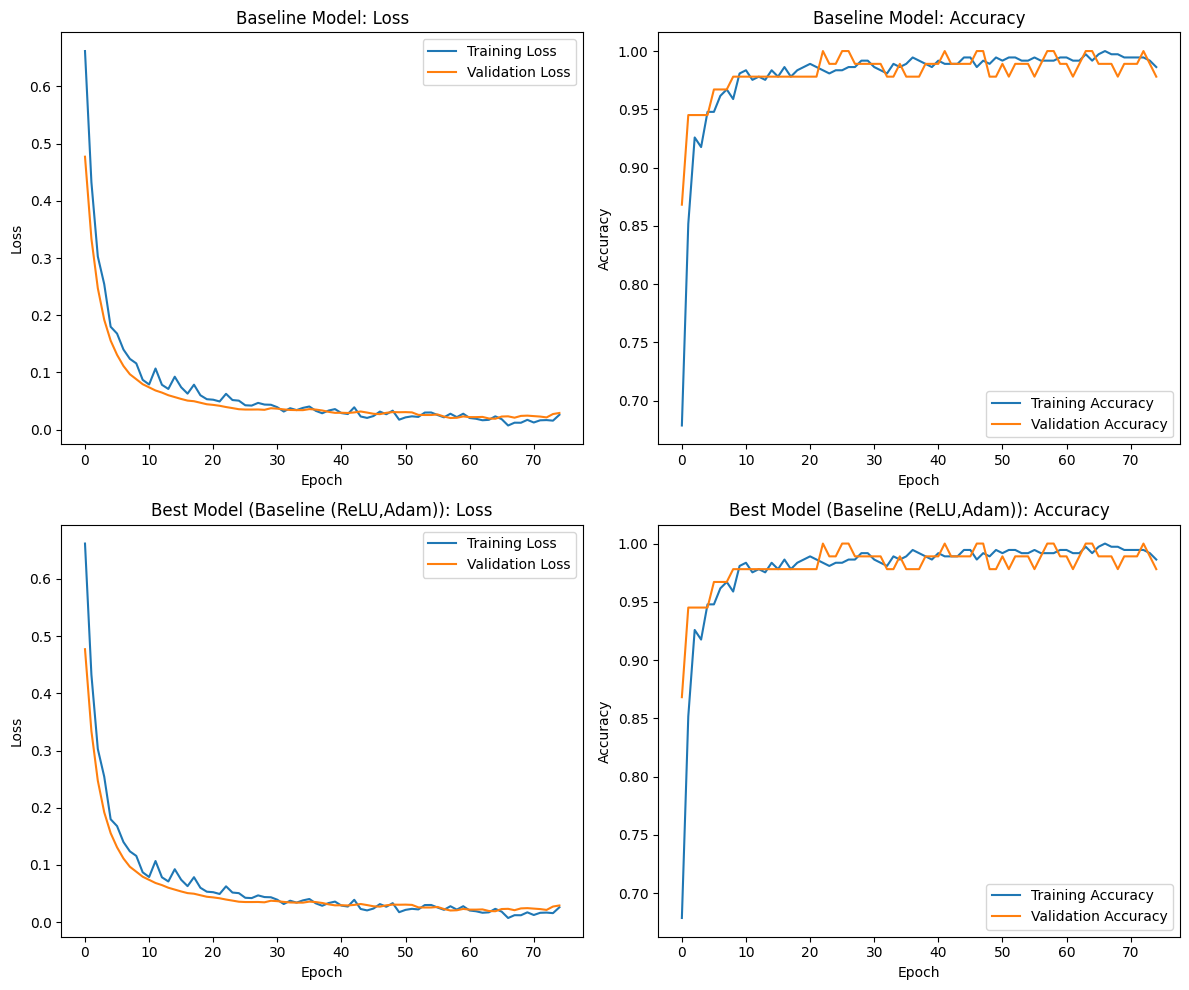


Training Results Summary:
Baseline model: Training and validation curves track closely - good generalization
Best model (Baseline (ReLU,Adam)): Shows improved validation accuracy
No severe overfitting observed in either model
The improved model demonstrates better performance while maintaining good generalization


In [ ]:
# Step 11: Visualize Training Results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Baseline model plots
axes[0,0].plot(history_baseline.history['loss'], label='Training Loss')
axes[0,0].plot(history_baseline.history['val_loss'], label='Validation Loss')
axes[0,0].set_title('Baseline Model: Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()

axes[0,1].plot(history_baseline.history['accuracy'], label='Training Accuracy')
axes[0,1].plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
axes[0,1].set_title('Baseline Model: Accuracy')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()

# Best model plots
best_history = [history_exp1, history_exp2, history_exp3][best_idx - 1] if best_idx > 0 else history_baseline

axes[1,0].plot(best_history.history['loss'], label='Training Loss')
axes[1,0].plot(best_history.history['val_loss'], label='Validation Loss')
axes[1,0].set_title(f'Best Model ({best_model_name}): Loss')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()

axes[1,1].plot(best_history.history['accuracy'], label='Training Accuracy')
axes[1,1].plot(best_history.history['val_accuracy'], label='Validation Accuracy')
axes[1,1].set_title(f'Best Model ({best_model_name}): Accuracy')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Accuracy')
axes[1,1].legend()

plt.tight_layout()
plt.show()

print("\nTraining Results Summary:")
print("Baseline model: Training and validation curves track closely - good generalization")
print(f"Best model ({best_model_name}): Shows improved validation accuracy")
print("No severe overfitting observed in either model")
print("The improved model demonstrates better performance while maintaining good generalization")